In [129]:
from scoresbibm.src.utils.data_utils import query, get_summary_df,load_model
from scoresbibm.src.utils.plot import plot_metric_by_num_simulations, use_style,multi_plot

from scoresbibm.src.tasks.unstructured_tasks import SIRTask, MultivariateNormal
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.core import rv

import matplotlib.pyplot as plt
import seaborn as sns

import jax
import jax.numpy as jnp
import os


In [49]:
task = SIRTask(time_end=40)

observation_generator = task.get_observation_generator()
reference_sampler = task.get_reference_sampler()
observation_stream = observation_generator(jax.random.PRNGKey(8))

In [211]:
COLOR_INFECTED = "darkorange"
COLOR_RECOVERED = "seagreen"
COLOR_DEATHS = "C3"
COLOR_PARAMETER = "royalblue"

In [5]:
model = load_model("../../../results/sir", 0)

In [50]:
data = task.get_data(100, rng=jax.random.PRNGKey(4))

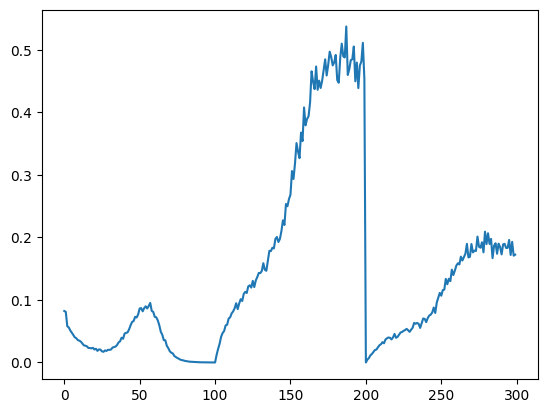

In [105]:
plt.plot(data["x"][95].T)

In [149]:
theta_o = data["theta"][95]
x_o = data["x"][95][::20]
ts_dense = jnp.linspace(0,40,100)
condition_mask = jnp.array([False]*2 + [False]*100 + [True if i%20==0 else False for i in range(300)])
meta_data = jnp.concatenate([jnp.array([jnp.nan, jnp.nan]),ts_dense, ts_dense,ts_dense,ts_dense])
node_id = jnp.array([0,1] + [2]*100 + [3]*100 + [4]*100 + [5]*100)

In [132]:
sample = model.sample(1000, x_o=x_o, condition_mask=condition_mask, meta_data=meta_data, rng=jax.random.PRNGKey(4))

In [154]:
theta12, betas, I, R,D = jnp.split(sample, [2,102, 197, 197 + 95 ], axis=-1)

betas_mean = jnp.mean(betas, axis=0)
betas_q01 = jnp.quantile(betas, 0.005, axis=0)
betas_q99 = jnp.quantile(betas, 0.995, axis=0)

I_mean = jnp.mean(I, axis=0)
I_q01 = jnp.quantile(I, 0.005, axis=0)
I_q99 = jnp.quantile(I, 0.995, axis=0)

R_mean = jnp.mean(R, axis=0)
R_q01 = jnp.quantile(R, 0.005, axis=0)
R_q99 = jnp.quantile(R, 0.995, axis=0)

D_mean = jnp.mean(D, axis=0)
D_q01 = jnp.quantile(D, 0.005, axis=0)
D_q99 = jnp.quantile(D, 0.995, axis=0)

In [166]:
import matplotlib.gridspec as gridspec

/tmp/ipykernel_51514/1887224867.py:6: UserWarning: 

`shade_lowest` has been replaced by `thresh`; setting `thresh=0.05.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=theta12[:,0], y=theta12[:,1], shade=True, shade_lowest=False, levels=50,cmap="Blues", ax=ax0)
/tmp/ipykernel_51514/1887224867.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=theta12[:,0], y=theta12[:,1], shade=True, shade_lowest=False, levels=50,cmap="Blues", ax=ax0)


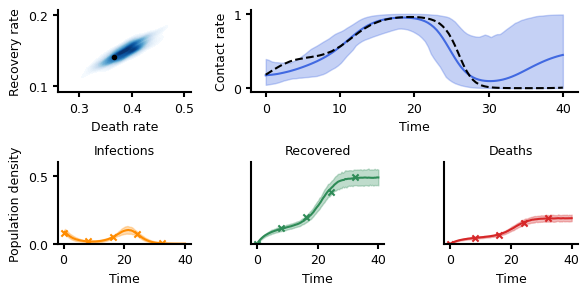

In [213]:
with use_style("pyloric"):
    fig = plt.figure(figsize=(6, 3))
    gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], width_ratios=[1, 1,1])
   
    ax0 = plt.subplot(gs[0, 0])
    sns.kdeplot(x=theta12[:,0], y=theta12[:,1], shade=True, shade_lowest=False, levels=50,cmap="Blues", ax=ax0)
    plt.scatter(theta_o[0], theta_o[1], color="black", marker="o")
    ax0.set_xlabel("Death rate")
    ax0.set_ylabel("Recovery rate")
   
    ax1 = plt.subplot(gs[0, 1:])
    _ = ax1.plot(ts_dense, betas_mean, color=COLOR_PARAMETER)
    _ = ax1.fill_between(ts_dense, betas_q01, betas_q99, alpha=0.3, color=COLOR_PARAMETER)
    _ = ax1.plot(ts_dense, theta_o[2:102], color="black", linestyle="--")
    ax1.set_ylabel("Contact rate")
    ax1.set_xlabel("Time")
    
    observations_means = (I_mean, R_mean, D_mean)
    observations_q01 = (I_q01, R_q01, D_q01)
    observations_q99 = (I_q99, R_q99, D_q99)
    titles = ("Infections", "Recovered", "Deaths")
    colors = (COLOR_INFECTED, COLOR_RECOVERED, COLOR_DEATHS)
    for i in range(3):
        ax = plt.subplot(gs[1,i])
        _ = ax.plot(ts_dense[~condition_mask[(i+1)*100+2:(i+2)*100+2]], observations_means[i], color=colors[i])
        _ = ax.fill_between(ts_dense[~condition_mask[(i+1)*100+2:(i+2)*100+2]], observations_q01[i], observations_q99[i], alpha=0.3, color=colors[i])
        _ = ax.scatter(ts_dense[condition_mask[(i+1)*100+2:(i+2)*100+2]], x_o[i*len(x_o)//3:(i+1)*len(x_o)//3], marker="x", s=20, color=colors[i])
        ax.set_title(titles[i])
        if i == 0:
            ax.set_ylabel("Population density")
        else:
            ax.set_yticks([])
        ax.set_xlabel("Time")
        ax.set_ylim(0,0.6)
        
    fig.tight_layout()
    fig.savefig("sir_example1.svg")
    
    

In [238]:
theta_o = data["theta"][95]
x_o = theta_o[2:][::30]
ts_dense = jnp.linspace(0,40,100)
condition_mask = jnp.array([False]*2 + [True if i%30==0 else False for i in range(100)] + [False if i%20==0 else False for i in range(300)])
meta_data = jnp.concatenate([jnp.array([jnp.nan, jnp.nan]),ts_dense, ts_dense,ts_dense,ts_dense])
node_id = jnp.array([0,1] + [2]*100 + [3]*100 + [4]*100 + [5]*100)

In [243]:
sample = model.sample(2000, x_o=x_o, condition_mask=condition_mask, meta_data=meta_data, rng=jax.random.PRNGKey(4))

2024-01-11 16:18:29.505930: W external/tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.83GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 5188105216 bytes.

In [240]:
theta12, betas, I, R,D = jnp.split(sample, [2,102-len(x_o), 102-len(x_o) + 100, 102-len(x_o) + 200 ], axis=-1)

betas_mean = jnp.mean(betas, axis=0)
betas_q01 = jnp.quantile(betas, 0.005, axis=0)
betas_q99 = jnp.quantile(betas, 0.995, axis=0)

I_mean = jnp.mean(I, axis=0)
I_q01 = jnp.quantile(I, 0.005, axis=0)
I_q99 = jnp.quantile(I, 0.995, axis=0)

R_mean = jnp.mean(R, axis=0)
R_q01 = jnp.quantile(R, 0.005, axis=0)
R_q99 = jnp.quantile(R, 0.995, axis=0)

D_mean = jnp.mean(D, axis=0)
D_q01 = jnp.quantile(D, 0.005, axis=0)
D_q99 = jnp.quantile(D, 0.995, axis=0)

/tmp/ipykernel_51514/865514664.py:6: UserWarning: 

`shade_lowest` has been replaced by `thresh`; setting `thresh=0.05.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=theta12[:,0], y=theta12[:,1], shade=True, shade_lowest=False, levels=50,cmap="Blues", ax=ax0)
/tmp/ipykernel_51514/865514664.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=theta12[:,0], y=theta12[:,1], shade=True, shade_lowest=False, levels=50,cmap="Blues", ax=ax0)


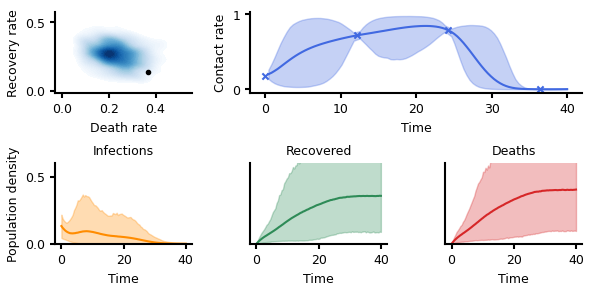

In [242]:
with use_style("pyloric"):
    fig = plt.figure(figsize=(6, 3))
    gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], width_ratios=[1, 1,1])
   
    ax0 = plt.subplot(gs[0, 0])
    sns.kdeplot(x=theta12[:,0], y=theta12[:,1], shade=True, shade_lowest=False, levels=50,cmap="Blues", ax=ax0)
    plt.scatter(theta_o[0], theta_o[1], color="black", marker="o")
    ax0.set_xlabel("Death rate")
    ax0.set_ylabel("Recovery rate")
   
    ax1 = plt.subplot(gs[0, 1:])
    _ = ax1.plot(ts_dense[~condition_mask[2:102]], betas_mean, color=COLOR_PARAMETER)
    _ = ax1.fill_between(ts_dense[~condition_mask[2:102]], betas_q01, betas_q99, alpha=0.3, color=COLOR_PARAMETER)
    _ = ax1.scatter(ts_dense[condition_mask[2:102]], x_o,marker="x", color=COLOR_PARAMETER, s=20)
    #_ = ax1.plot(ts_dense, theta_o[2:102], color="black", linestyle="--")
    ax1.set_ylabel("Contact rate")
    ax1.set_xlabel("Time")
    
    observations_means = (I_mean, R_mean, D_mean)
    observations_q01 = (I_q01, R_q01, D_q01)
    observations_q99 = (I_q99, R_q99, D_q99)
    titles = ("Infections", "Recovered", "Deaths")
    colors = (COLOR_INFECTED, COLOR_RECOVERED, COLOR_DEATHS)
    for i in range(3):
        ax = plt.subplot(gs[1,i])
        _ = ax.plot(ts_dense[~condition_mask[(i+1)*100+2:(i+2)*100+2]], observations_means[i], color=colors[i])
        _ = ax.fill_between(ts_dense[~condition_mask[(i+1)*100+2:(i+2)*100+2]], observations_q01[i], observations_q99[i], alpha=0.3, color=colors[i])
        #_ = ax.scatter(ts_dense[condition_mask[(i+1)*100+2:(i+2)*100+2]], x_o[i*len(x_o)//3:(i+1)*len(x_o)//3], marker="x", s=20, color=colors[i])
        ax.set_title(titles[i])
        if i == 0:
            ax.set_ylabel("Population density")
        else:
            ax.set_yticks([])
        ax.set_xlabel("Time")
        ax.set_ylim(0,0.6)
        
    fig.tight_layout()
    fig.savefig("sir_example_emulation.svg")
    
    